<a href="https://colab.research.google.com/github/plasma-wastaken/REFFTO-PROJECTS/blob/main/loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('loandata.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.shape


(4269, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=["loan_id"," commercial_assets_value"," luxury_assets_value"], inplace=True)

In [ ]:
df.shape

(4269, 10)

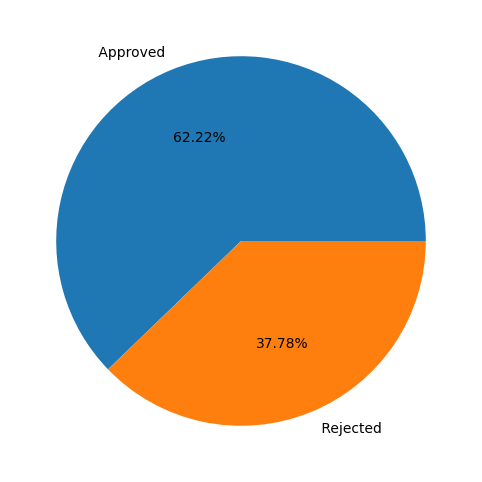

In [ ]:
df.columns = df.columns.str.strip()
plt.figure(figsize=(8,6))
plt.pie(df['loan_status'].value_counts(),labels=df['loan_status'].value_counts().index,autopct='%1.2f%%')
plt.show()

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'bank_asset_value'],
      dtype='object')

In [ ]:
df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()

In [ ]:
df["education"] = df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

df["self_employed"] = df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

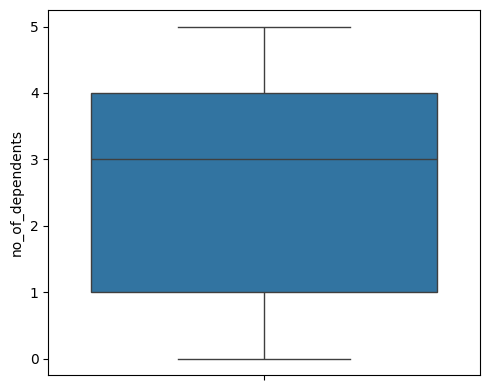

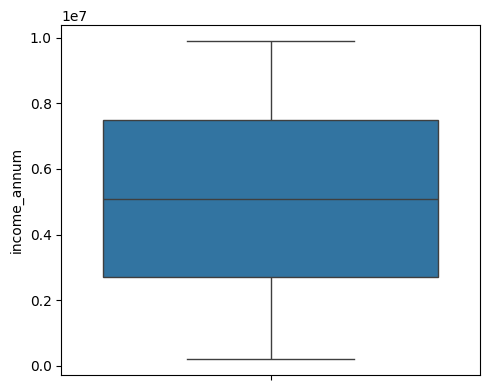

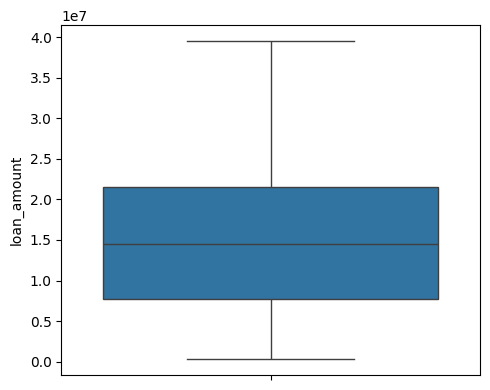

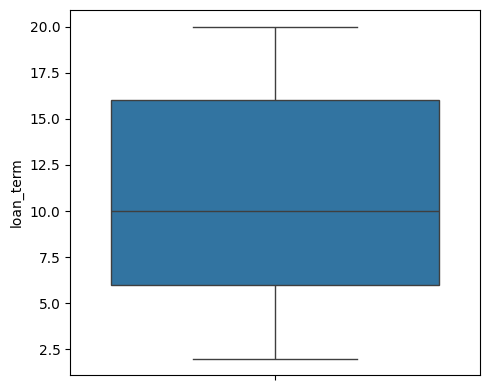

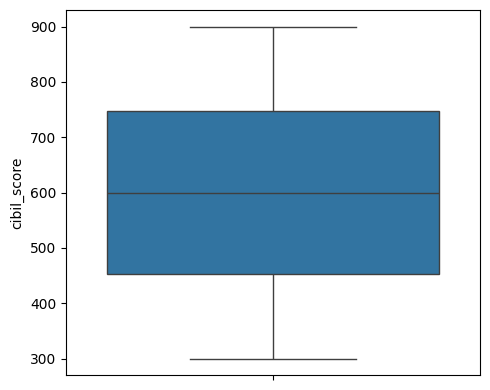

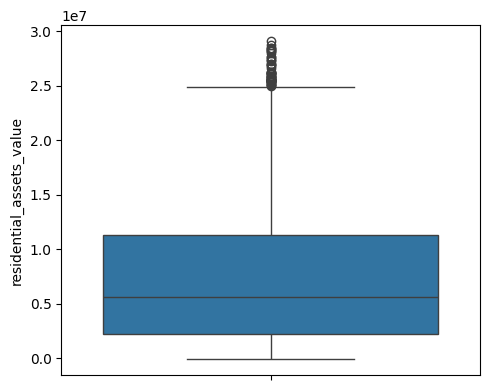

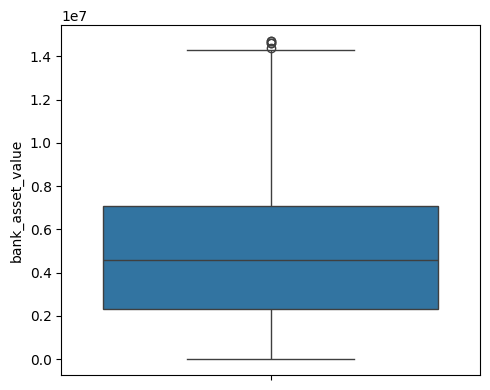

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(df[col])
    plt.tight_layout()
    plt.show()

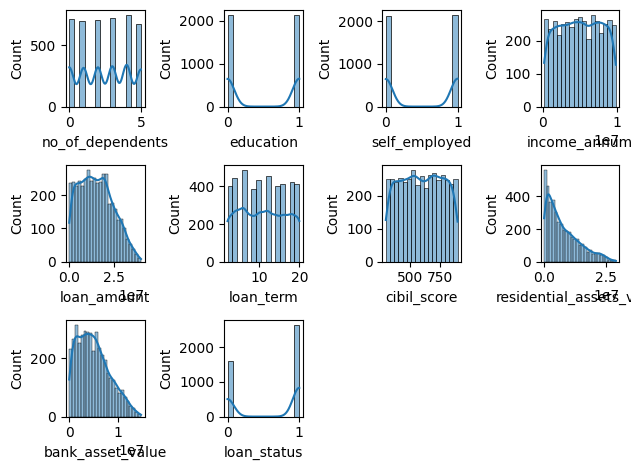

In [ ]:
def plotting(var, num):
    plt.subplot(3,4,num) # Adjusted subplot grid
    sns.histplot(df[var], kde=True)

plotting('no_of_dependents', 1)
plotting('education', 2)
plotting('self_employed', 3)
plotting('income_annum', 4)
plotting('loan_amount', 5)
plotting('loan_term', 6)
plotting('cibil_score', 7)
plotting('residential_assets_value', 8)
plotting('bank_asset_value', 9)
plotting('loan_status', 10)

plt.tight_layout()
plt.show()

<Axes: >

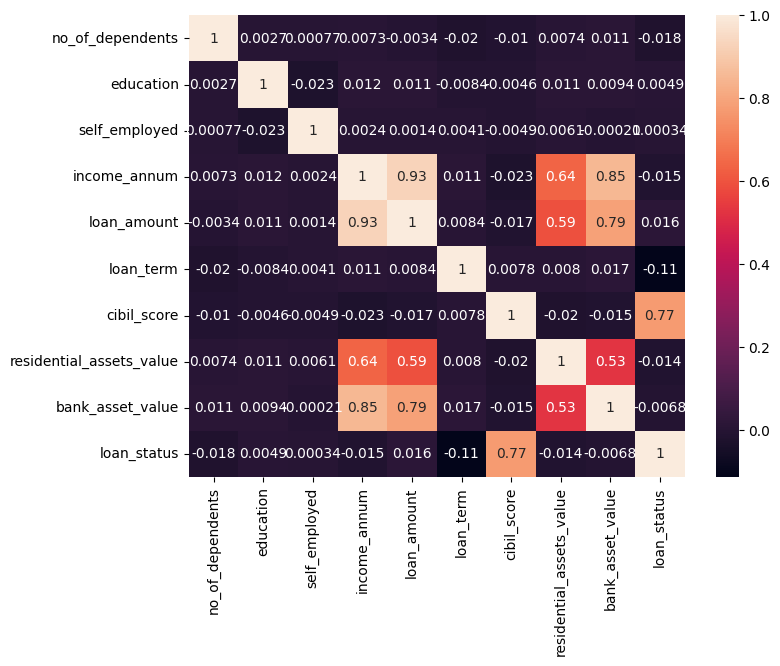

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [ ]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression()
model.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9028103044496487


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9765807962529274


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9765807962529274


In [ ]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)

svm = SVC(random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.9344262295081968


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9004683840749415


In [ ]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9391100702576113


In [ ]:
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm
}

for name, preds in models.items():
    print(name, "->", accuracy_score(y_test, preds))


Logistic Regression -> 0.9028103044496487
Decision Tree -> 0.9765807962529274
Random Forest -> 0.9765807962529274
KNN -> 0.9004683840749415
Naive Bayes -> 0.9391100702576113
SVM -> 0.9344262295081968


In [ ]:
import joblib
joblib_file = "loan_model.pkl"
joblib.dump(rf, "randomforest.pkl")


['randomforest.pkl']